In [1]:
print("Hello World")

Hello World


In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [3]:
words = [
    "dogs", "cat", "pet",
    "king", "queen", "kingdom",
    "car", "bus", "vehicle"
]

vectorizer = TfidfVectorizer()
embeddings = vectorizer.fit_transform(words).toarray()

print(f"Embedding for 'dog': {embeddings[0]}")

Embedding for 'dog': [0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [7]:
# SImilarity

similarity_matrix = cosine_similarity(embeddings)

for i, word in enumerate(words):
    similarities = [
        f"{words[j]}: {similarity_matrix[i][j]}"
        for j in range(len(words))
    ]
    print(f"{word} -> {similarities}")

dogs -> ['dogs: 1.0', 'cat: 0.0', 'pet: 0.0', 'king: 0.0', 'queen: 0.0', 'kingdom: 0.0', 'car: 0.0', 'bus: 0.0', 'vehicle: 0.0']
cat -> ['dogs: 0.0', 'cat: 1.0', 'pet: 0.0', 'king: 0.0', 'queen: 0.0', 'kingdom: 0.0', 'car: 0.0', 'bus: 0.0', 'vehicle: 0.0']
pet -> ['dogs: 0.0', 'cat: 0.0', 'pet: 1.0', 'king: 0.0', 'queen: 0.0', 'kingdom: 0.0', 'car: 0.0', 'bus: 0.0', 'vehicle: 0.0']
king -> ['dogs: 0.0', 'cat: 0.0', 'pet: 0.0', 'king: 1.0', 'queen: 0.0', 'kingdom: 0.0', 'car: 0.0', 'bus: 0.0', 'vehicle: 0.0']
queen -> ['dogs: 0.0', 'cat: 0.0', 'pet: 0.0', 'king: 0.0', 'queen: 1.0', 'kingdom: 0.0', 'car: 0.0', 'bus: 0.0', 'vehicle: 0.0']
kingdom -> ['dogs: 0.0', 'cat: 0.0', 'pet: 0.0', 'king: 0.0', 'queen: 0.0', 'kingdom: 1.0', 'car: 0.0', 'bus: 0.0', 'vehicle: 0.0']
car -> ['dogs: 0.0', 'cat: 0.0', 'pet: 0.0', 'king: 0.0', 'queen: 0.0', 'kingdom: 0.0', 'car: 1.0', 'bus: 0.0', 'vehicle: 0.0']
bus -> ['dogs: 0.0', 'cat: 0.0', 'pet: 0.0', 'king: 0.0', 'queen: 0.0', 'kingdom: 0.0', 'car: 0.

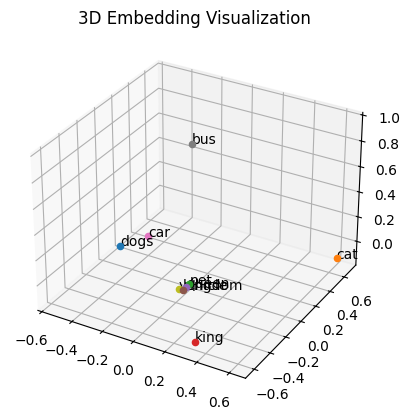

In [9]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=3)
reduced_3d = pca.fit_transform(embeddings)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for i, word in enumerate(words):
    x, y, z = reduced_3d[i]
    ax.scatter(x, y, z)
    ax.text(x, y, z, word)

ax.set_title("3D Embedding Visualization")
plt.show()

In [11]:
import gensim.downloader as api

model = api.load("glove-wiki-gigaword-50")

In [12]:
embeddings = [model[word] for word in words]

In [13]:
import numpy as np

embeddings_array = np.array(embeddings)
similarity_matrix = cosine_similarity(embeddings_array)

print("----- Printing Similarity Matrix -----")

for i, word in enumerate(words):
    similarities = [
        f"{words[j]}: {similarity_matrix[i][j]:.2f}"
        for j in range(len(words))
    ]
    print(f"{word} -> {similarities}")    

----- Printing Similarity Matrix -----
dogs -> ['dogs: 1.00', 'cat: 0.78', 'pet: 0.71', 'king: 0.18', 'queen: 0.25', 'kingdom: 0.15', 'car: 0.40', 'bus: 0.42', 'vehicle: 0.42']
cat -> ['dogs: 0.78', 'cat: 1.00', 'pet: 0.78', 'king: 0.39', 'queen: 0.47', 'kingdom: 0.26', 'car: 0.36', 'bus: 0.31', 'vehicle: 0.31']
pet -> ['dogs: 0.71', 'cat: 0.78', 'pet: 1.00', 'king: 0.20', 'queen: 0.25', 'kingdom: 0.11', 'car: 0.37', 'bus: 0.32', 'vehicle: 0.34']
king -> ['dogs: 0.18', 'cat: 0.39', 'pet: 0.20', 'king: 1.00', 'queen: 0.78', 'kingdom: 0.75', 'car: 0.26', 'bus: 0.21', 'vehicle: 0.10']
queen -> ['dogs: 0.25', 'cat: 0.47', 'pet: 0.25', 'king: 0.78', 'queen: 1.00', 'kingdom: 0.66', 'car: 0.29', 'bus: 0.29', 'vehicle: 0.15']
kingdom -> ['dogs: 0.15', 'cat: 0.26', 'pet: 0.11', 'king: 0.75', 'queen: 0.66', 'kingdom: 1.00', 'car: 0.18', 'bus: 0.23', 'vehicle: 0.14']
car -> ['dogs: 0.40', 'cat: 0.36', 'pet: 0.37', 'king: 0.26', 'queen: 0.29', 'kingdom: 0.18', 'car: 1.00', 'bus: 0.82', 'vehicle: 0

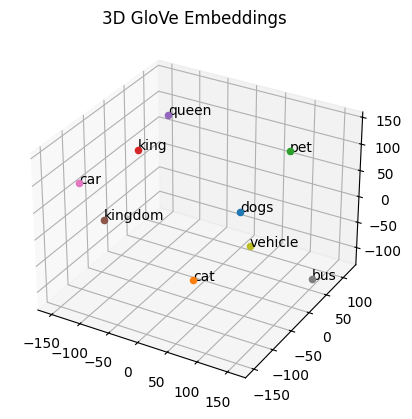

In [15]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=3, perplexity=3, random_state=42)
reduced = tsne.fit_transform(embeddings_array)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for i, word in enumerate(words):
    x, y, z = reduced[i]
    ax.scatter(x, y, z)
    ax.text(x, y, z, word)

plt.title("3D GloVe Embeddings")
plt.show()

In [16]:
print(model.most_similar("cat"))

[('dog', 0.9218006134033203), ('rabbit', 0.8487821221351624), ('monkey', 0.8041081428527832), ('rat', 0.7891963124275208), ('cats', 0.7865270376205444), ('snake', 0.7798910737037659), ('dogs', 0.7795814871788025), ('pet', 0.7792249321937561), ('mouse', 0.773166835308075), ('bite', 0.7728800177574158)]
